# InceptentionNet Baseline (Notebook)

This notebook mirrors the repository implementation for the baseline paper:
- Data prep (MB vs non-MB)
- Preprocessing + augmentation
- InceptentionNet model
- 5-fold cross-validation training
- Evaluation against paper-reported metrics

In [9]:
from __future__ import annotations

import hashlib
import json
import random
from dataclasses import dataclass
from pathlib import Path
import os

import numpy as np
import torch
import torch.nn as nn
import yaml
from PIL import Image, ImageFilter, ImageOps
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm import tqdm

import os
import random
from pathlib import Path

import numpy as np
from PIL import Image, ImageFilter, ImageOps

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from tqdm import tqdm

## Configuration

/kaggle/input/datasets/waseemnagahhenes/brain-tumor-for-14-classes/BrainTumor/Meduloblastoma

In [10]:
CONFIG = {

    "seed": 42,

    "data": {
        "data_root": "/kaggle/input/datasets/waseemnagahhenes/brain-tumor-for-14-classes/BrainTumor",
        "mb_class_name": "Meduloblastoma",
        "mb_target_count": 106,
        "non_mb_target_count": 630,
        "image_size": 224,
    },

    "training": {
        "batch_size": 16,
        "num_folds": 5,
        "max_epochs": 40,
        "learning_rate": 1e-4,
        "weight_decay": 1e-4,
        "num_workers": 2,
        "early_stopping_patience": 10
    },

    "model": {
        "stem_channels": 64,
        "branch_channels": 64,
        "attention_heads": 4,
        "dropout": 0.3
    }

}

## Utilities

In [11]:
def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(CONFIG["seed"])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## Transforms

In [12]:
class GaussianAndEqualize:

    def __call__(self, image):

        image = image.filter(ImageFilter.GaussianBlur(radius=0.7))
        image = ImageOps.equalize(image)

        return image


def build_train_transform(image_size):

    return transforms.Compose([

        transforms.Resize((image_size, image_size)),

        GaussianAndEqualize(),

        transforms.RandomHorizontalFlip(),

        transforms.RandomRotation(10),

        transforms.ColorJitter(
            brightness=0.1,
            contrast=0.1
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=(0.5,0.5,0.5),
            std=(0.5,0.5,0.5)
        )

    ])


def build_eval_transform(image_size):

    return transforms.Compose([

        transforms.Resize((image_size,image_size)),

        GaussianAndEqualize(),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=(0.5,0.5,0.5),
            std=(0.5,0.5,0.5)
        )

    ])

## Dataset

In [13]:
class BrainDataset(Dataset):

    def __init__(self, samples, transform):

        self.samples = samples
        self.transform = transform


    def __len__(self):

        return len(self.samples)


    def __getitem__(self, idx):

        path, label = self.samples[idx]

        image = Image.open(path).convert("RGB")

        image = self.transform(image)

        return image, torch.tensor(label).float()

In [14]:
IMAGE_EXT = [".png",".jpg",".jpeg",".bmp",".tif",".tiff"]


def list_images(folder):

    images=[]

    for root,_,files in os.walk(folder):

        for f in files:

            if any(f.lower().endswith(e) for e in IMAGE_EXT):

                images.append(os.path.join(root,f))

    return images


def build_samples(data_root):

    root=Path(data_root)

    mb_dir=root/CONFIG["data"]["mb_class_name"]

    mb_images=list_images(mb_dir)

    non_mb_images=[]

    for d in root.iterdir():

        if d.name==CONFIG["data"]["mb_class_name"]:
            continue

        non_mb_images.extend(list_images(d))


    mb_images=mb_images[:CONFIG["data"]["mb_target_count"]]
    non_mb_images=non_mb_images[:CONFIG["data"]["non_mb_target_count"]]


    samples=[]

    for p in mb_images:
        samples.append((p,1))

    for p in non_mb_images:
        samples.append((p,0))


    random.shuffle(samples)

    return samples

In [15]:
class ConvBNReLU(nn.Module):

    def __init__(self, in_c, out_c, k, s=1, p=0):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(in_c,out_c,kernel_size=k,stride=s,padding=p,bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)

        )


    def forward(self,x):
        return self.block(x)

Total samples  : 736
  MB  (label=1): 106
  Non-MB (label=0): 630


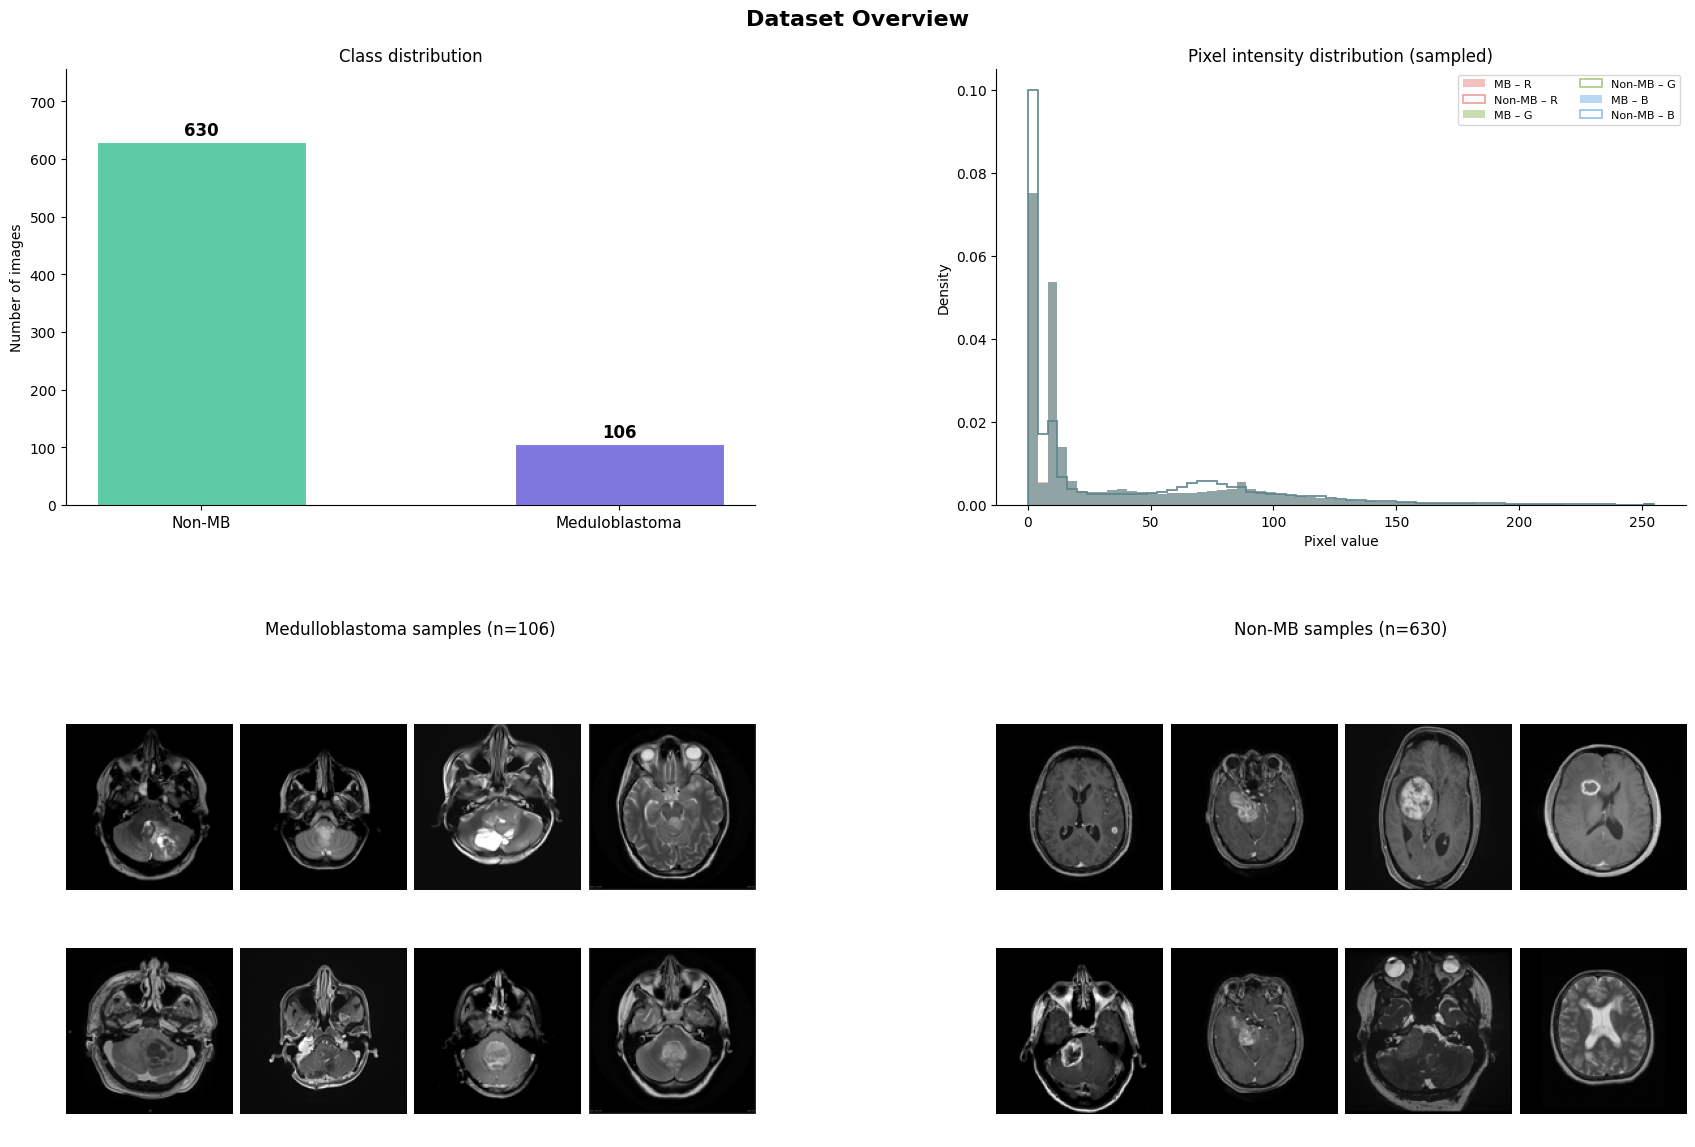

Saved → dataset_overview.png


In [16]:
# ── Dataset Visualization ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from PIL import Image

# ── 1. Build samples (re-use existing helper) ─────────────────────────────────
viz_samples = build_samples(CONFIG["data"]["data_root"])  # list of (path, label)

mb_samples  = [(p, l) for p, l in viz_samples if l == 1]
non_mb      = [(p, l) for p, l in viz_samples if l == 0]

print(f"Total samples  : {len(viz_samples)}")
print(f"  MB  (label=1): {len(mb_samples)}")
print(f"  Non-MB (label=0): {len(non_mb)}")


# ── 2. Helper: load & resize ──────────────────────────────────────────────────
def load_img(path, size=128):
    return np.array(Image.open(path).convert("RGB").resize((size, size)))


# ── 3. Figure layout ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Dataset Overview", fontsize=16, fontweight="bold", y=0.98)

outer = gridspec.GridSpec(2, 2, figure=fig,
                          hspace=0.45, wspace=0.35,
                          left=0.06, right=0.96,
                          top=0.93, bottom=0.04)


# ── Panel A: Class distribution bar chart ────────────────────────────────────
ax_dist = fig.add_subplot(outer[0, 0])

classes = ["Non-MB", "Meduloblastoma"]
counts  = [len(non_mb), len(mb_samples)]
colors  = ["#5DCAA5", "#7F77DD"]

bars = ax_dist.bar(classes, counts, color=colors, width=0.5,
                   edgecolor="white", linewidth=0.8)
for bar, count in zip(bars, counts):
    ax_dist.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 5,
                 str(count),
                 ha="center", va="bottom", fontsize=12, fontweight="bold")

ax_dist.set_title("Class distribution", fontsize=12)
ax_dist.set_ylabel("Number of images")
ax_dist.set_ylim(0, max(counts) * 1.2)
ax_dist.spines[["top", "right"]].set_visible(False)
ax_dist.tick_params(axis="x", labelsize=11)


# ── Panel B: Pixel intensity histogram (mean across each class) ───────────────
ax_hist = fig.add_subplot(outer[0, 1])

N_HIST = 30   # images sampled per class for speed

def mean_channel_hist(sample_list, n=N_HIST):
    chosen = random.sample(sample_list, min(n, len(sample_list)))
    pixels = np.concatenate(
        [load_img(p).reshape(-1, 3) for p, _ in chosen], axis=0
    )
    return pixels

mb_pix    = mean_channel_hist(mb_samples)
non_mb_px = mean_channel_hist(non_mb)

bins = np.linspace(0, 255, 64)
for ch_idx, ch_name, ch_color in zip(range(3), ["R", "G", "B"],
                                     ["#E24B4A", "#639922", "#378ADD"]):
    ax_hist.hist(mb_pix[:, ch_idx],    bins=bins, alpha=0.35,
                 color=ch_color, label=f"MB – {ch_name}", density=True,
                 histtype="stepfilled")
    ax_hist.hist(non_mb_px[:, ch_idx], bins=bins, alpha=0.55,
                 color=ch_color, label=f"Non-MB – {ch_name}", density=True,
                 histtype="step", linewidth=1.2)

ax_hist.set_title("Pixel intensity distribution (sampled)", fontsize=12)
ax_hist.set_xlabel("Pixel value")
ax_hist.set_ylabel("Density")
ax_hist.legend(fontsize=8, ncol=2)
ax_hist.spines[["top", "right"]].set_visible(False)


# ── Panel C: MB sample grid ───────────────────────────────────────────────────
N_GRID = 8
inner_mb = gridspec.GridSpecFromSubplotSpec(
    2, N_GRID // 2, subplot_spec=outer[1, 0], hspace=0.05, wspace=0.05
)
chosen_mb = random.sample(mb_samples, min(N_GRID, len(mb_samples)))
for i, (path, _) in enumerate(chosen_mb):
    ax = fig.add_subplot(inner_mb[i // (N_GRID // 2), i % (N_GRID // 2)])
    ax.imshow(load_img(path))
    ax.axis("off")
fig.add_subplot(outer[1, 0]).set_title(
    f"Medulloblastoma samples (n={len(mb_samples)})",
    fontsize=12, pad=48
)
fig.axes[-1].axis("off")


# ── Panel D: Non-MB sample grid ───────────────────────────────────────────────
inner_non = gridspec.GridSpecFromSubplotSpec(
    2, N_GRID // 2, subplot_spec=outer[1, 1], hspace=0.05, wspace=0.05
)
chosen_non = random.sample(non_mb, min(N_GRID, len(non_mb)))
for i, (path, _) in enumerate(chosen_non):
    ax = fig.add_subplot(inner_non[i // (N_GRID // 2), i % (N_GRID // 2)])
    ax.imshow(load_img(path))
    ax.axis("off")
fig.add_subplot(outer[1, 1]).set_title(
    f"Non-MB samples (n={len(non_mb)})",
    fontsize=12, pad=48
)
fig.axes[-1].axis("off")


plt.savefig("dataset_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → dataset_overview.png")


## InceptentionNet Model

In [36]:
class InceptionBlock(nn.Module):

    def __init__(self, in_c, branch_c=64):

        super().__init__()

        self.b1 = ConvBNReLU(in_c,branch_c,1)

        self.b2 = ConvBNReLU(in_c,branch_c,3,p=1)

        self.b3 = ConvBNReLU(in_c,branch_c,5,p=2)

        self.b4 = ConvBNReLU(in_c,branch_c,3,s=2,p=1)

        self.down = ConvBNReLU(branch_c*4,branch_c*4,3,s=2,p=1)


    def forward(self,x):

        b1 = self.b1(x)
        b2 = self.b2(x)
        b3 = self.b3(x)
        b4 = self.b4(x)

        h = min(b1.shape[-2],b2.shape[-2],b3.shape[-2],b4.shape[-2])
        w = min(b1.shape[-1],b2.shape[-1],b3.shape[-1],b4.shape[-1])

        b1=b1[:,:,:h,:w]
        b2=b2[:,:,:h,:w]
        b3=b3[:,:,:h,:w]
        b4=b4[:,:,:h,:w]

        x = torch.cat([b1,b2,b3,b4],dim=1)

        return self.down(x)

## Training and Evaluation Functions

In [37]:
class SEBlock(nn.Module):

    def __init__(self, channels, reduction=16):

        super().__init__()

        self.fc = nn.Sequential(

            nn.Linear(channels,channels//reduction),
            nn.ReLU(),
            nn.Linear(channels//reduction,channels),
            nn.Sigmoid()

        )


    def forward(self,x):

        b,c,h,w = x.shape

        y = x.mean((2,3))

        y = self.fc(y).view(b,c,1,1)

        return x*y

In [38]:
class SelfAttention2D(nn.Module):

    def __init__(self, embed_dim, heads):

        super().__init__()

        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=heads,
            batch_first=True
        )

        self.norm = nn.LayerNorm(embed_dim)


    def forward(self,x):

        b,c,h,w = x.shape

        tokens = x.view(b,c,h*w).transpose(1,2)

        attn,_ = self.attn(tokens,tokens,tokens)

        out = self.norm(tokens+attn)

        return out.transpose(1,2).view(b,c,h,w)

## Run 5-Fold Training

Uncomment and run this cell after dependencies finish installing.

In [39]:
class InceptentionNet(nn.Module):

    def __init__(self):

        super().__init__()

        stem_c = CONFIG["model"]["stem_channels"]
        branch_c = CONFIG["model"]["branch_channels"]

        self.stem = ConvBNReLU(3,stem_c,3,p=1)

        self.inception = InceptionBlock(stem_c,branch_c)

        embed_dim = branch_c*4

        self.se = SEBlock(embed_dim)

        self.attn = SelfAttention2D(
            embed_dim,
            CONFIG["model"]["attention_heads"]
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(embed_dim,128),
            nn.ReLU(),

            nn.Dropout(CONFIG["model"]["dropout"]),

            nn.Linear(128,1)

        )


    def forward(self,x):

        x = self.stem(x)

        x = self.inception(x)

        x = self.se(x)

        x = self.attn(x)

        x = self.pool(x)

        x = self.classifier(x)

        return x.squeeze(1)

## Compare Results to Paper

In [40]:
def evaluate(model,loader):

    model.eval()

    targets=[]
    probs=[]

    with torch.no_grad():

        for x,y in loader:

            x=x.to(DEVICE)
            y=y.to(DEVICE)

            logits=model(x)

            p=torch.sigmoid(logits)

            probs.extend(p.cpu().numpy())
            targets.extend(y.cpu().numpy())


    preds=[1 if p>=0.5 else 0 for p in probs]

    return {

        "accuracy":accuracy_score(targets,preds),
        "precision":precision_score(targets,preds,zero_division=0),
        "recall":recall_score(targets,preds,zero_division=0),
        "f1":f1_score(targets,preds,zero_division=0),
        "auc":roc_auc_score(targets,probs)

    }

In [41]:
def train_fold(train_samples,val_samples):

    train_transform=build_train_transform(CONFIG["data"]["image_size"])
    eval_transform=build_eval_transform(CONFIG["data"]["image_size"])


    train_dataset=BrainDataset(train_samples,train_transform)
    val_dataset=BrainDataset(val_samples,eval_transform)


    labels=[s[1] for s in train_samples]

    class_counts=np.bincount(labels)

    weights=1./class_counts

    sample_weights=[weights[l] for l in labels]

    sampler=WeightedRandomSampler(sample_weights,len(sample_weights))


    train_loader=DataLoader(
        train_dataset,
        batch_size=CONFIG["training"]["batch_size"],
        sampler=sampler,
        num_workers=CONFIG["training"]["num_workers"],
        pin_memory=True
    )

    val_loader=DataLoader(
        val_dataset,
        batch_size=CONFIG["training"]["batch_size"],
        shuffle=False,
        num_workers=CONFIG["training"]["num_workers"],
        pin_memory=True
    )


    model=InceptentionNet()

    if torch.cuda.device_count() > 1:
        print("Using", torch.cuda.device_count(), "GPUs")
        model = torch.nn.DataParallel(model)

        model = model.to(DEVICE)

    


    optimizer=torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG["training"]["learning_rate"],
        weight_decay=CONFIG["training"]["weight_decay"]
    )


    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=CONFIG["training"]["max_epochs"]
    )


    criterion=nn.BCEWithLogitsLoss()

    scaler=torch.cuda.amp.GradScaler()


    best_loss=1e9
    patience=0


    for epoch in range(CONFIG["training"]["max_epochs"]):

        model.train()

        losses=[]

        for x,y in tqdm(train_loader):

            x=x.to(DEVICE)
            y=y.to(DEVICE)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():

                logits=model(x)

                loss=criterion(logits,y)

            scaler.scale(loss).backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)

            scaler.step(optimizer)

            scaler.update()

            losses.append(loss.item())


        scheduler.step()

        val_metrics=evaluate(model,val_loader)

        val_loss=np.mean(losses)

        print("Epoch:",epoch,val_metrics)


        if val_loss<best_loss:

            best_loss=val_loss
            patience=0

        else:

            patience+=1

        if patience>=CONFIG["training"]["early_stopping_patience"]:
            break


    return val_metrics

In [42]:
samples=build_samples(CONFIG["data"]["data_root"])

labels=np.array([s[1] for s in samples])

skf=StratifiedKFold(
    n_splits=CONFIG["training"]["num_folds"],
    shuffle=True,
    random_state=CONFIG["seed"]
)

results=[]

for fold,(train_idx,val_idx) in enumerate(skf.split(np.zeros(len(samples)),labels)):

    print("\nFOLD",fold+1)

    train_samples=[samples[i] for i in train_idx]
    val_samples=[samples[i] for i in val_idx]

    metrics=train_fold(train_samples,val_samples)

    results.append(metrics)


print("\nFINAL RESULTS")

for r in results:
    print(r)


FOLD 1
Using 2 GPUs


/tmp/ipykernel_5818/2990597055.py:65: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=torch.cuda.amp.GradScaler()
  0%|          | 0/37 [00:00<?, ?it/s]/tmp/ipykernel_5818/2990597055.py:85: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 37/37 [00:08<00:00,  4.31it/s]


Epoch: 0 {'accuracy': 0.8513513513513513, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'auc': np.float64(0.7492784992784993)}


  0%|          | 0/37 [00:00<?, ?it/s]/tmp/ipykernel_5818/2990597055.py:85: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 37/37 [00:06<00:00,  5.34it/s]


Epoch: 1 {'accuracy': 0.7027027027027027, 'precision': 0.2708333333333333, 'recall': 0.5909090909090909, 'f1': 0.37142857142857144, 'auc': np.float64(0.7485569985569985)}


...

Epoch: 37 {'accuracy': 0.9523809523809523, 'precision': 0.7692307692307693, 'recall': 0.9523809523809523, 'f1': 0.851063829787234, 'auc': np.float64(0.992063492063492)}


  0%|          | 0/37 [00:00<?, ?it/s]/tmp/ipykernel_5818/2990597055.py:85: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 37/37 [00:06<00:00,  5.31it/s]


Epoch: 38 {'accuracy': 0.9387755102040817, 'precision': 0.7142857142857143, 'recall': 0.9523809523809523, 'f1': 0.8163265306122449, 'auc': np.float64(0.990551776266062)}


  0%|          | 0/37 [00:00<?, ?it/s]/tmp/ipykernel_5818/2990597055.py:85: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 37/37 [00:06<00:00,  5.37it/s]


Epoch: 39 {'accuracy': 0.9523809523809523, 'precision': 0.7692307692307693, 'recall': 0.9523809523809523, 'f1': 0.851063829787234, 'auc': np.float64(0.9924414210128496)}

FINAL RESULTS
{'accuracy': 0.9256756756756757, 'precision': 0.6896551724137931, 'recall': 0.9090909090909091, 'f1': 0.7843137254901961, 'auc': np.float64(0.9808802308802309)}
{'accuracy': 0.9523809523809523, 'precision': 0.7692307692307693, 'recall': 0.9523809523809523, 'f1': 0.851063829787234, 'auc': np.float64(0.9894179894179894)}
{'accuracy': 0.9183673469387755, 'precision': 0.6363636363636364, 'recall': 1.0, 'f1': 0.7777777777777778, 'auc': np.float64(0.9837490551776266)}
{'accuracy': 0.9047619047619048, 'precision': 0.6129032258064516, 'recall': 0.9047619047619048, 'f1': 0.7307692307692307, 'auc': np.float64(0.9769463340891912)}
{'accuracy': 0.9523809523809523, 'precision': 0.7692307692307693, 'recall': 0.9523809523809523, 'f1': 0.851063829787234, 'auc': np.float64(0.9924414210128496)}


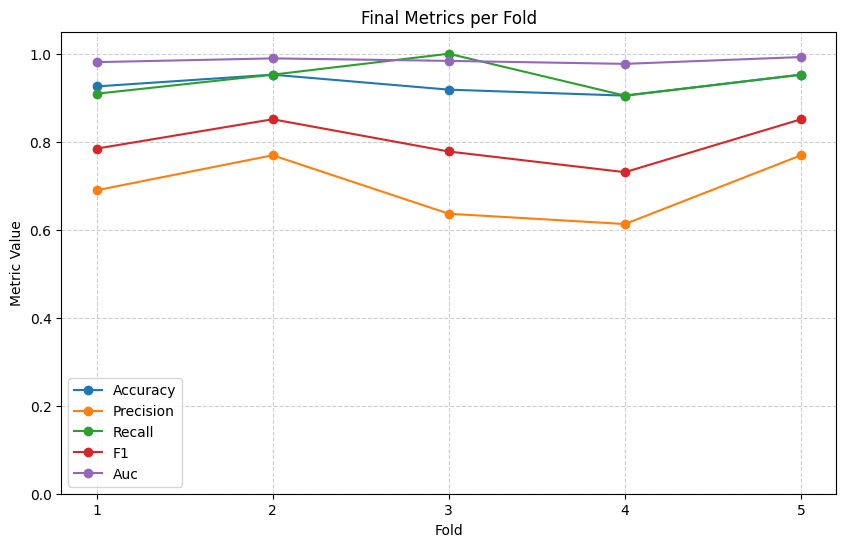

In [55]:
import matplotlib.pyplot as plt
import numpy as np

def plot_final_metrics_line(results):
    """
    Plot final metrics per fold as line plots.
    results: list of dicts, each containing final metrics for a fold
    """
    metrics = ["accuracy", "precision", "recall", "f1", "auc"]
    num_folds = len(results)
    folds = np.arange(1, num_folds + 1)

    plt.figure(figsize=(10, 6))

    for metric in metrics:
        values = [r[metric] for r in results]
        plt.plot(folds, values, marker='o', label=metric.capitalize())

    plt.xticks(folds)
    plt.ylim(0, 1.05)
    plt.xlabel("Fold")
    plt.ylabel("Metric Value")
    plt.title("Final Metrics per Fold")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

plot_final_metrics_line(results)

In [56]:
metrics_keys = ["accuracy", "precision", "recall", "f1", "auc"]

final_metrics = {}
for key in metrics_keys:
    values = np.array([fold[key] for fold in results], dtype=np.float64)
    final_metrics[key] = float(values.mean())

print("Final Aggregated Metrics Across Folds:")
for k, v in final_metrics.items():
    print(f"{k:10s}: {v:.4f}")

Final Aggregated Metrics Across Folds:
accuracy  : 0.9307
precision : 0.6955
recall    : 0.9437
f1        : 0.7990
auc       : 0.9847
